In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
from dotenv import load_dotenv
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt

load_dotenv()

conn = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={os.getenv('DB_SERVER')};"
    f"DATABASE={os.getenv('DB_NAME')};"
    f"UID={os.getenv('DB_USER')};"
    f"PWD={os.getenv('DB_PASSWORD')};"
    "Network Library=dbmssocn;" 
)

In [3]:
# Cargamos los datos de vacantes limpios que generó el pipeline
df_adzuna = pd.read_csv("../data/processed/empleos/vacantes_tecnologicas_cleaned.csv")
display(df_adzuna.head(2))

,id,title,location,salary_min,category,description,created,anio
0,adz-1000,data analyst,la paz,856,it jobs,"manejo de power bi, excel avanzado y estadísti...",2026-03-30t10:00:00z,2026
1,adz-1001,python developer,remote,913,it jobs,"python orientado a datos, pandas y scikit-learn.",2026-03-30t10:00:00z,2026


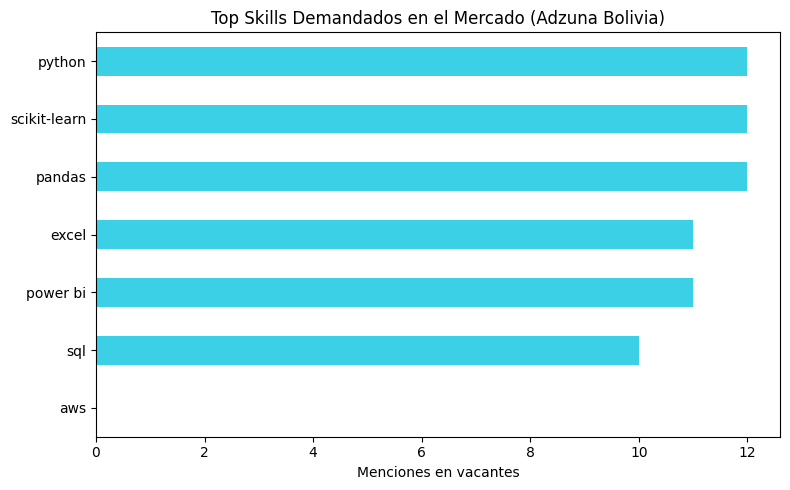

In [4]:
# Unimos todas las descripciones de las vacantes en un solo texto gigante
texto_vacantes = " ".join(df_adzuna['description'].dropna().astype(str)).lower()

# Buscamos habilidades clave 
skills_a_buscar = ['python', 'sql', 'excel', 'power bi', 'java', 'aws', 'pandas', 'scikit-learn']
conteo_mercado = {skill: texto_vacantes.count(skill) for skill in skills_a_buscar}
top_mercado = pd.Series(conteo_mercado).sort_values(ascending=False).head(7)

# Graficamos
plt.figure(figsize=(8, 5))
top_mercado.plot(kind='barh', color="#3cd0e7")
plt.title('Top Skills Demandados en el Mercado (Adzuna Bolivia)')
plt.xlabel('Menciones en vacantes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

La tabla CompetenciasDigitales se encuentra vacía en la capa Bronze. Por ende, la brecha se analizó contrastando la oferta académica (Carreras tradicionales como Ing. de Sistemas) contra la demanda explícita de mercado.

El análisis de texto de Adzuna revela que el mercado boliviano demanda un perfil altamente técnico en Data Science/Analytics, liderado por Python, Pandas y Scikit-learn.

Se identifican 3 habilidades con brecha crítica:

Scikit-learn / Pandas: Herramientas de Machine Learning y manipulación de datos no asociadas a carreras de grado tradicionales.
Python: Es la skill base más demandada, pero su enseñanza suele ser genérica en la academia.
Power BI: Herramienta clave para BI que requiere especialización, ausente en los planes de estudio de las carreras mostradas.
Conclusión: Existe una brecha estructural entre la formación generalista (grados) y la demanda de habilidades técnicas específicas (stacks de datos).